In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

In [12]:
data = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Order_raw_data.csv"
df = pd.read_csv(data).replace("noData",np.nan)
print(df.columns)

Index(['oms_version', 'id', 'order_item_id', 'type', 'flow_type',
       'order_external_id', 'checkout_id', 'status', 'net_filter_flag', 'gmv',
       ...
       'updated_at', 'brand_classification_key', 'is_large', 'cms_vertical',
       'is_bulk_order', 'order_sales_app', 'order_sales_experience',
       'order_tags', 'unit_tags', 'is_extra_saver_flag'],
      dtype='object', length=227)


In [17]:
features = ['gmv', 'mrp', 'listing_price', 'order_payment_type', 
    'order_sales_channel', 'pincode', 'category_id', 
    'is_fk_assured', 'new_customer_flag', 'order_item_unit_discount']
target = 'unit_is_rtod'
le = LabelEncoder()
cat_cols = ['order_payment_type', 'order_sales_channel', 'category_id', 'new_customer_flag']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df[target] = le.fit_transform(df[target].astype(str))
target_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(f"Target mapping: {target_mapping}")
df[features] = df[features].fillna(0)

X= df[features]
y=df[target]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Target mapping: {np.int64(0): '0', np.int64(1): '1', np.int64(2): '2'}
Accuracy : 0.8907684871918802
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     54035
           1       0.26      0.05      0.09      5966

    accuracy                           0.89     60001
   macro avg       0.58      0.52      0.52     60001
weighted avg       0.84      0.89      0.86     60001



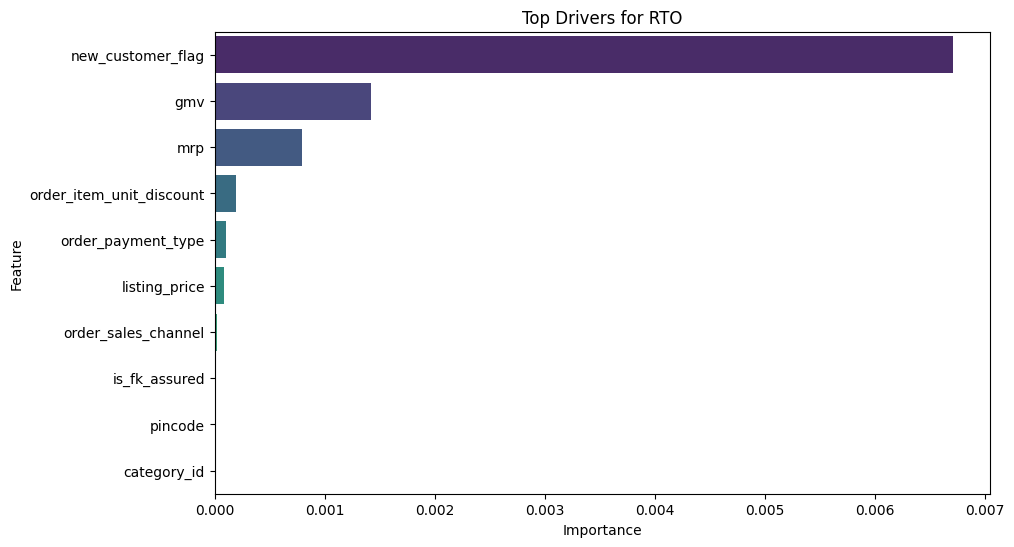

In [23]:
results = permutation_importance(nb_model, X_test, y_test, n_repeats = 10, random_state = 42)
drivers_df = pd.DataFrame({
    'Feature': features,
    'Importance': results.importances_mean
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=drivers_df.head(10), x= 'Importance', y='Feature', palette = 'viridis')
plt.title("Top Drivers for RTO")
plt.show()

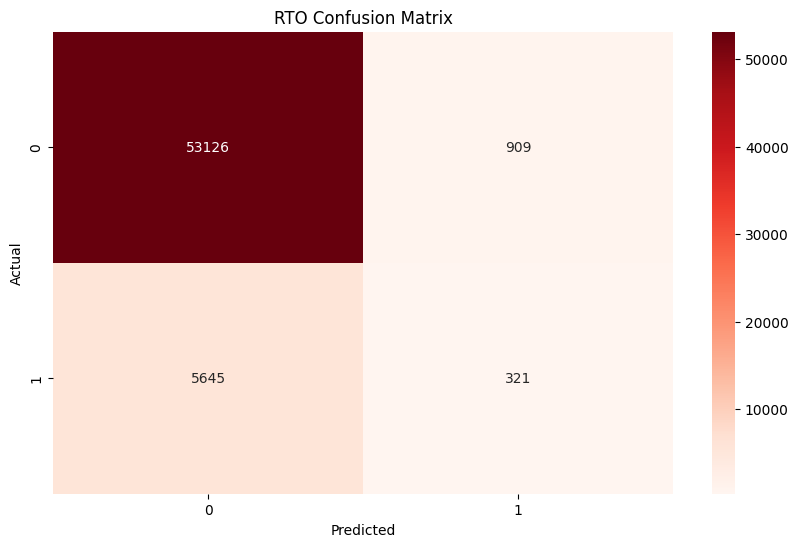

In [25]:
cm =confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("RTO Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

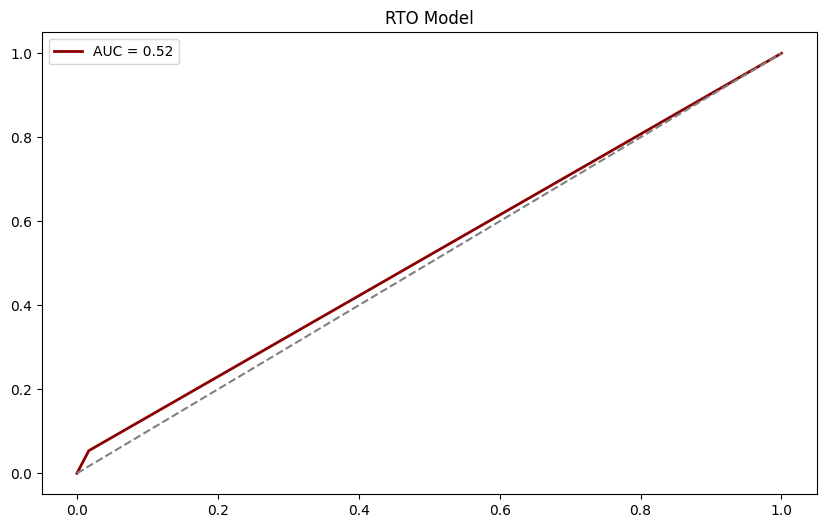

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, label =f'AUC = {roc_auc:.2f}', color='darkred', lw=2)
plt.plot([0,1],[0,1], linestyle='--', color='grey')
plt.title("RTO Model")
plt.xlabel = ('Flase Positive Rate')
plt.ylabel = ('True Positive Rate')
plt.legend()
plt.show()